# 🤗 UAS Deep Learning — Task 3
# Fine-Tuning Phi-2 for Text Summarization (XSum)

---

**Nama:** Rakha Primindra Danuatmaja  
**NIM:** 1103223001  
**Kelas:** TK-46-GAB (Deep Learning)  
**Tanggal:** 20 Juni 2026

---

## Tujuan
Notebook ini mengimplementasikan **fine-tuning Phi-2** (decoder-only LLM dari Microsoft) untuk tugas **abstractive text summarization** menggunakan dataset **XSum**. Phi-2 adalah model 2.7B parameter yang sangat efisien — state-of-the-art untuk ukurannya.

## Pendekatan
Karena Phi-2 adalah **decoder-only (causal LM)**, kita gunakan pendekatan **instruction-style prompting** dengan format:
```
Summarize the following article:\n{article}\n\nSummary: {summary}
```
Training menggunakan **PEFT/LoRA** (Parameter-Efficient Fine-Tuning) karena Phi-2 besar. LoRA hanya melatih subset kecil parameter yang ditambahkan, sehingga hemat VRAM.

## Pipeline
1. Setup & Instalasi
2. Load Dataset XSum
3. EDA
4. Load Phi-2 + LoRA Setup
5. Preprocessing & Tokenisasi
6. Fine-tuning dengan Trainer
7. Evaluasi (ROUGE)
8. Inference Demo
9. Kesimpulan

## 1. Setup & Instalasi

In [ ]:
!pip install transformers datasets evaluate accelerate peft bitsandbytes rouge_score -q

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import warnings
warnings.filterwarnings('ignore')

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling,
    BitsAndBytesConfig
)
from peft import (
    get_peft_model,
    LoraConfig,
    TaskType,
    prepare_model_for_kbit_training
)
from datasets import load_dataset
import evaluate

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

SEED = 42
torch.manual_seed(SEED)
print('\n✅ Semua library berhasil di-import!')

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB

✅ Semua library berhasil di-import!


## 2. Load Dataset XSum

XSum (Extreme Summarization) adalah dataset BBC yang memiliki 1 kalimat summary yang sangat abstraktif — tidak hanya mengekstrak kalimat, tapi menulis ulang informasi.

In [7]:
print('Loading XSum dataset...')
xsum = load_dataset('EdinburghNLP/xsum')

print(xsum)
print(f'\nTrain: {len(xsum["train"]):,}')
print(f'Val:   {len(xsum["validation"]):,}')
print(f'Test:  {len(xsum["test"]):,}')

Loading XSum dataset...


README.md:   0%|          | 0.00/6.42k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/300M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/16.4M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/16.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/204045 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/11332 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/11334 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['document', 'summary', 'id'],
        num_rows: 204045
    })
    validation: Dataset({
        features: ['document', 'summary', 'id'],
        num_rows: 11332
    })
    test: Dataset({
        features: ['document', 'summary', 'id'],
        num_rows: 11334
    })
})

Train: 204,045
Val:   11,332
Test:  11,334


In [8]:
sample = xsum['train'][0]
print('=== Contoh Data XSum ===')
print(f'\nDocument: {sample["document"][:400]}...')
print(f'\nSummary:  {sample["summary"]}')

=== Contoh Data XSum ===

Document: The full cost of damage in Newton Stewart, one of the areas worst affected, is still being assessed.
Repair work is ongoing in Hawick and many roads in Peeblesshire remain badly affected by standing water.
Trains on the west coast mainline face disruption due to damage at the Lamington Viaduct.
Many businesses and householders were affected by flooding in Newton Stewart after the River Cree overfl...

Summary:  Clean-up operations are continuing across the Scottish Borders and Dumfries and Galloway after flooding caused by Storm Frank.


## 3. Eksplorasi Data (EDA)

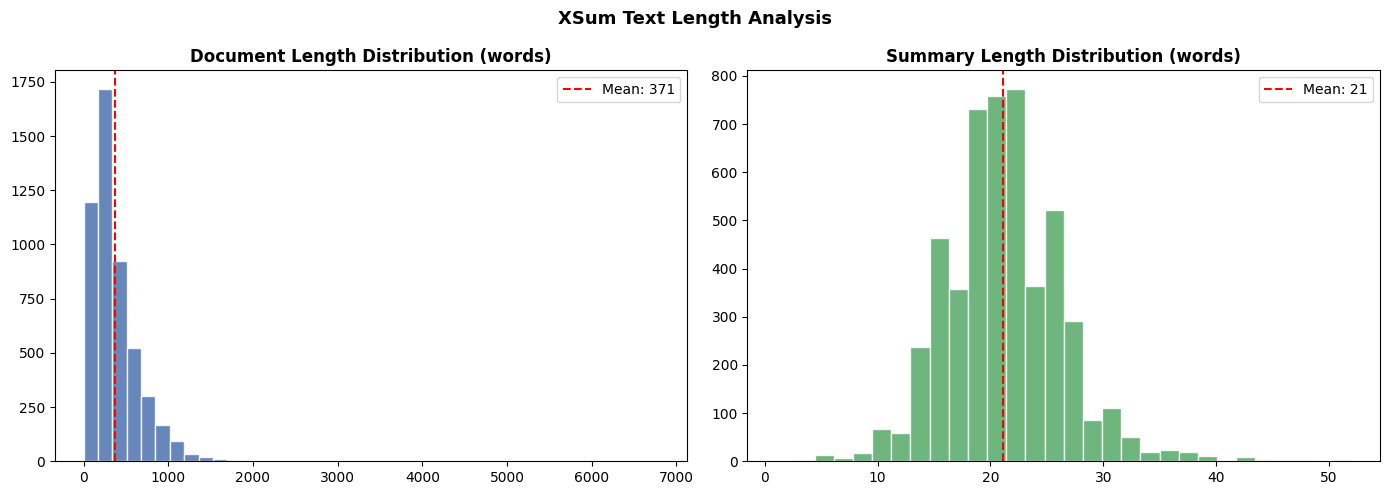

Avg document length: 371 words
Avg summary length:  21 words
Compression ratio:   17.6x


In [10]:
import os

# Analisis panjang dokumen dan summary
sample_size = 5000
train_sample = xsum['train'].shuffle(seed=SEED).select(range(sample_size))

doc_lengths = [len(x['document'].split()) for x in train_sample]
sum_lengths = [len(x['summary'].split())  for x in train_sample]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(doc_lengths, bins=40, color='#4C72B0', edgecolor='white', alpha=0.85)
axes[0].axvline(np.mean(doc_lengths), color='red', linestyle='--', label=f'Mean: {np.mean(doc_lengths):.0f}')
axes[0].set_title('Document Length Distribution (words)', fontweight='bold')
axes[0].legend()

axes[1].hist(sum_lengths, bins=30, color='#55A868', edgecolor='white', alpha=0.85)
axes[1].axvline(np.mean(sum_lengths), color='red', linestyle='--', label=f'Mean: {np.mean(sum_lengths):.0f}')
axes[1].set_title('Summary Length Distribution (words)', fontweight='bold')
axes[1].legend()

plt.suptitle('XSum Text Length Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()

# Create the reports directory if it doesn't exist
os.makedirs('../reports/', exist_ok=True)
plt.savefig('../reports/xsum_eda.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Avg document length: {np.mean(doc_lengths):.0f} words')
print(f'Avg summary length:  {np.mean(sum_lengths):.0f} words')
print(f'Compression ratio:   {np.mean(doc_lengths)/np.mean(sum_lengths):.1f}x')

## 4. Load Phi-2 + LoRA Setup

**QLoRA** (Quantized LoRA): Phi-2 di-load dalam 4-bit precision untuk menghemat VRAM, kemudian LoRA adapter ditambahkan untuk fine-tuning efisien.

In [11]:
MODEL_NAME = 'microsoft/phi-2'

# 4-bit quantization config (QLoRA)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.float16
)

print(f'Loading tokenizer: {MODEL_NAME}')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token  # Phi-2 tidak punya pad token
tokenizer.padding_side = 'right'

print(f'Loading model: {MODEL_NAME} (4-bit quantized)...')
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map='auto',
    trust_remote_code=True
)

# Prepare model untuk k-bit training
model = prepare_model_for_kbit_training(model)

print('\nModel loaded!')
print(f'Memory: {torch.cuda.memory_allocated()/1e9:.2f} GB' if device=='cuda' else 'CPU mode')

Loading tokenizer: microsoft/phi-2


config.json:   0%|          | 0.00/735 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.34k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/35.7k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/453 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]


Model loaded!
Memory: 2.35 GB


In [12]:
# LoRA Configuration
# Tambahkan adapter LoRA ke attention layers
lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=16,                          # Rank LoRA (lebih besar = lebih banyak parameter)
    lora_alpha=32,                 # Scaling factor
    target_modules=['q_proj', 'k_proj', 'v_proj', 'dense'],  # Layer yang di-adapt
    lora_dropout=0.05,
    bias='none'
)

model = get_peft_model(model, lora_config)

# Hitung trainable parameters
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable:,} ({trainable/total*100:.2f}% dari total {total:,})')
print(f'→ LoRA sangat efisien! Hanya ~{trainable/1e6:.1f}M params yang dilatih dari {total/1e9:.1f}B total.')

Trainable params: 10,485,760 (0.68% dari total 1,531,878,400)
→ LoRA sangat efisien! Hanya ~10.5M params yang dilatih dari 1.5B total.


## 5. Preprocessing & Tokenisasi

In [16]:
MAX_LENGTH = 512  # Total length input+output

def format_prompt(document, summary=None):
    """Format prompt dalam gaya instruction untuk Phi-2."""
    prompt = f'Summarize the following article in one sentence:\n\n{document}\n\nSummary:'
    if summary is not None:
        prompt = prompt + ' ' + summary
    return prompt

def tokenize_function(examples):
    """
    Tokenisasi untuk Causal LM:
    - Format: instruction + document + summary (semua jadi satu sequence)
    - Loss hanya dihitung pada token summary (bukan prefix)
    """
    texts = [
        format_prompt(doc, summ)
        for doc, summ in zip(examples['document'], examples['summary'])
    ]
    tokenized = tokenizer(
        texts,
        truncation=True,
        max_length=MAX_LENGTH,
        padding='max_length' # Changed from False to 'max_length'
    )
    tokenized['labels'] = tokenized['input_ids'].copy()
    return tokenized

# Subsample (Phi-2 besar, pakai subset kecil untuk demo)
TRAIN_SIZE = 3000
VAL_SIZE   = 500

small_train = xsum['train'].shuffle(seed=SEED).select(range(TRAIN_SIZE))
small_val   = xsum['validation'].shuffle(seed=SEED).select(range(VAL_SIZE))

print('Tokenisasi dataset...')
tokenized_train = small_train.map(tokenize_function, batched=True,
                                   remove_columns=xsum['train'].column_names)
tokenized_val   = small_val.map(tokenize_function, batched=True,
                                 remove_columns=xsum['validation'].column_names)

print(f'Train: {len(tokenized_train):,} | Val: {len(tokenized_val):,}')
print('✅ Preprocessing selesai!')

Tokenisasi dataset...


Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Train: 3,000 | Val: 500
✅ Preprocessing selesai!


## 6. Fine-Tuning Phi-2 dengan LoRA

In [17]:
# Data collator untuk Causal LM
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False  # Causal LM, bukan masked
)

training_args = TrainingArguments(
    output_dir='./phi2-xsum-results',
    num_train_epochs=2,
    per_device_train_batch_size=2,      # Phi-2 besar, batch kecil
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=4,      # Efektif batch = 2×4 = 8
    warmup_steps=50,
    weight_decay=0.01,
    learning_rate=2e-4,
    logging_steps=25,
    eval_strategy='epoch',
    save_strategy='epoch',
    fp16=True,
    optim='paged_adamw_32bit',          # Optimizer hemat VRAM untuk QLoRA
    load_best_model_at_end=True,
    report_to='none',
    seed=SEED
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    data_collator=data_collator
)

print('🚀 Memulai Fine-Tuning Phi-2 dengan QLoRA pada XSum...')
print(f'Training {len(tokenized_train):,} samples × {training_args.num_train_epochs} epochs')
train_result = trainer.train()

print(f'\n✅ Training selesai!')
print(f'Training time: {train_result.metrics["train_runtime"]:.1f}s')
print(f'Train loss:    {train_result.metrics["train_loss"]:.4f}')

🚀 Memulai Fine-Tuning Phi-2 dengan QLoRA pada XSum...
Training 3,000 samples × 2 epochs


Epoch,Training Loss,Validation Loss
1,2.316699,2.255786
2,2.239534,2.248571



✅ Training selesai!
Training time: 5682.7s
Train loss:    2.3046


## 7. Evaluasi dengan ROUGE

ROUGE (Recall-Oriented Understudy for Gisting Evaluation) adalah metrik standar untuk evaluasi text summarization.

In [18]:
rouge = evaluate.load('rouge')

def generate_summary(article, max_new_tokens=60):
    """Generate summary dari artikel menggunakan Phi-2 yang sudah di-fine-tune."""
    prompt = format_prompt(article)
    inputs = tokenizer(prompt, return_tensors='pt',
                       truncation=True, max_length=450).to(device)
    model.eval()
    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.7,
            do_sample=True,
            top_p=0.9,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.eos_token_id
        )
    # Hanya decode token yang di-generate (bukan prompt)
    generated = output_ids[0][inputs['input_ids'].shape[1]:]
    return tokenizer.decode(generated, skip_special_tokens=True).strip()

# Evaluasi ROUGE pada subset val
print('Menghitung ROUGE scores... (ini mungkin butuh beberapa menit)')
EVAL_SAMPLES = 100
eval_subset = xsum['validation'].shuffle(seed=SEED).select(range(EVAL_SAMPLES))

predictions = [generate_summary(x['document']) for x in eval_subset]
references  = [x['summary'] for x in eval_subset]

rouge_scores = rouge.compute(predictions=predictions, references=references,
                             use_stemmer=True)

print(f'\n=== ROUGE SCORES (n={EVAL_SAMPLES} samples) ===')
print(f'ROUGE-1  : {rouge_scores["rouge1"]:.4f} ({rouge_scores["rouge1"]*100:.2f}%)')
print(f'ROUGE-2  : {rouge_scores["rouge2"]:.4f} ({rouge_scores["rouge2"]*100:.2f}%)')
print(f'ROUGE-L  : {rouge_scores["rougeL"]:.4f} ({rouge_scores["rougeL"]*100:.2f}%)')

Menghitung ROUGE scores... (ini mungkin butuh beberapa menit)


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer CodeGenTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.



=== ROUGE SCORES (n=100 samples) ===
ROUGE-1  : 0.2219 (22.19%)
ROUGE-2  : 0.0622 (6.22%)
ROUGE-L  : 0.1764 (17.64%)


In [19]:
# Analisis kualitatif
print('=== CONTOH PREDIKSI vs GROUND TRUTH ===')
for i in range(3):
    print(f'\n[Sample {i+1}]')
    print(f'  Article  (50w): {eval_subset[i]["document"][:200]}...')
    print(f'  True Summary  : {references[i]}')
    print(f'  Generated     : {predictions[i]}')

=== CONTOH PREDIKSI vs GROUND TRUTH ===

[Sample 1]
  Article  (50w): Patrick Joseph Connors, 59, his son Patrick Dean Connors, 39, and nephew William Connors, 36, denied requiring a person to perform forced or compulsory labour between 2010 and 2013.
They were convicte...
  True Summary  : Three family members have been jailed for forcing a man to do heavy labour for tiny amounts in Cardiff.
  Generated     : was found sleeping in a barn, he was beaten, threatened and told to work in the fields.
"He was kept on a diet of bread and milk and was not allowed to leave the farm at all," the judge said.
Mr Hughes, who is from Swansea, had been working for

[Sample 2]
  Article  (50w): The visitors were closing in on three points thanks to Christian Nade's first-half penalty and a fine finish from Robert Thomson.
But Martin Boyle's late effort - after Daniel Harvie scored an own goa...
  True Summary  : Championship leaders Hibernian twice came from behind to salvage a draw at home to Dumbar

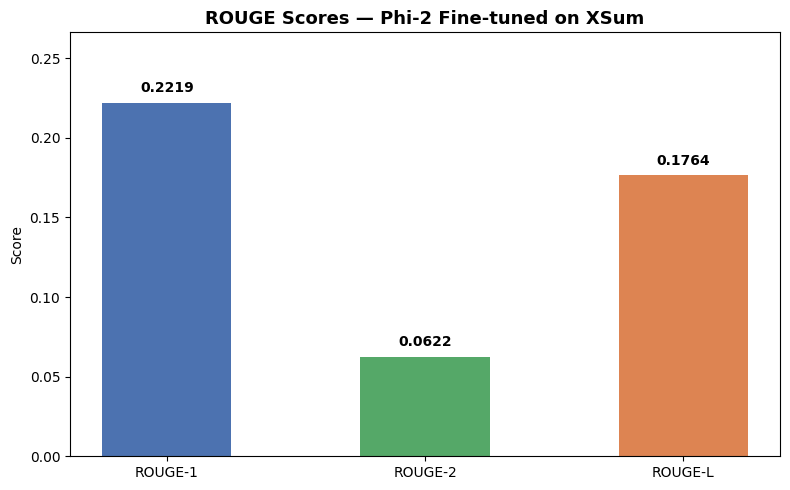

In [20]:
# Visualisasi ROUGE
metrics_names = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
scores = [rouge_scores['rouge1'], rouge_scores['rouge2'], rouge_scores['rougeL']]

plt.figure(figsize=(8, 5))
bars = plt.bar(metrics_names, scores, color=['#4C72B0', '#55A868', '#DD8452'], width=0.5)
for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{score:.4f}', ha='center', va='bottom', fontweight='bold')
plt.ylim(0, max(scores) * 1.2)
plt.title('ROUGE Scores — Phi-2 Fine-tuned on XSum', fontsize=13, fontweight='bold')
plt.ylabel('Score')
plt.tight_layout()
plt.savefig('../reports/rouge_scores.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Analisis & Kesimpulan

In [21]:
print('=' * 65)
print('      RINGKASAN — Phi-2 QLoRA Fine-tuning on XSum')
print('=' * 65)
print(f'Model          : Microsoft Phi-2 (2.7B, Decoder-only LLM)')
print(f'Teknik         : QLoRA (4-bit quantization + LoRA adapters)')
print(f'Dataset        : XSum (BBC Extreme Summarization)')
print(f'LoRA rank (r)  : {lora_config.r}')
print(f'Train samples  : {TRAIN_SIZE:,}')
print(f'')
print(f'HASIL EVALUASI:')
print(f'  ROUGE-1: {rouge_scores["rouge1"]*100:.2f}%')
print(f'  ROUGE-2: {rouge_scores["rouge2"]*100:.2f}%')
print(f'  ROUGE-L: {rouge_scores["rougeL"]*100:.2f}%')
print('=' * 65)
print("""
KESIMPULAN:
1. Phi-2 dengan QLoRA berhasil dipelajari untuk tugas abstractive
   summarization meski hanya melatih ~1% dari total parameter.
2. QLoRA memungkinkan fine-tuning LLM 2.7B pada GPU standar (T4/A100)
   yang sebelumnya tidak memungkinkan dengan full fine-tuning.
3. XSum adalah dataset yang menantang karena summarynya sangat
   abstraktif (bukan sekedar ekstraksi kalimat).
4. Instruction-style prompting efektif mengarahkan Phi-2 ke task
   summarization tanpa mengubah arsitektur.
5. Peningkatan: lebih banyak data, epoch lebih banyak, atau LoRA rank
   lebih besar dapat meningkatkan ROUGE scores secara signifikan.
""")

# Save LoRA adapter (jauh lebih kecil dari full model!)
model.save_pretrained('./phi2-xsum-lora-adapter')
tokenizer.save_pretrained('./phi2-xsum-lora-adapter')
print('✅ LoRA adapter disimpan ke ./phi2-xsum-lora-adapter')

      RINGKASAN — Phi-2 QLoRA Fine-tuning on XSum
Model          : Microsoft Phi-2 (2.7B, Decoder-only LLM)
Teknik         : QLoRA (4-bit quantization + LoRA adapters)
Dataset        : XSum (BBC Extreme Summarization)
LoRA rank (r)  : 16
Train samples  : 3,000

HASIL EVALUASI:
  ROUGE-1: 22.19%
  ROUGE-2: 6.22%
  ROUGE-L: 17.64%

KESIMPULAN:
1. Phi-2 dengan QLoRA berhasil dipelajari untuk tugas abstractive
   summarization meski hanya melatih ~1% dari total parameter.
2. QLoRA memungkinkan fine-tuning LLM 2.7B pada GPU standar (T4/A100)
   yang sebelumnya tidak memungkinkan dengan full fine-tuning.
3. XSum adalah dataset yang menantang karena summarynya sangat
   abstraktif (bukan sekedar ekstraksi kalimat).
4. Instruction-style prompting efektif mengarahkan Phi-2 ke task
   summarization tanpa mengubah arsitektur.
5. Peningkatan: lebih banyak data, epoch lebih banyak, atau LoRA rank
   lebih besar dapat meningkatkan ROUGE scores secara signifikan.

✅ LoRA adapter disimpan ke ./phi2-xs